# Ecommerce Customer Churn — EDA & NA Cleaning

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Dataset

In [2]:
df = pd.read_csv("data/Ecommerce Customer Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 3. Explore Missing Values

In [3]:
print("=== dtypes & non-null counts ===")
df.info()

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null 

In [4]:
na_count = df.isnull().sum()
na_pct   = (na_count / len(df) * 100).round(2)
na_summary = pd.DataFrame({"NA Count": na_count, "NA %": na_pct})
na_summary = na_summary[na_summary["NA Count"] > 0].sort_values("NA Count", ascending=False)
print(na_summary)

                             NA Count  NA %
DaySinceLastOrder                 307  5.45
OrderAmountHikeFromlastYear       265  4.71
Tenure                            264  4.69
OrderCount                        258  4.58
CouponUsed                        256  4.55
HourSpendOnApp                    255  4.53
WarehouseToHome                   251  4.46


## 4. Visualise Missing Data

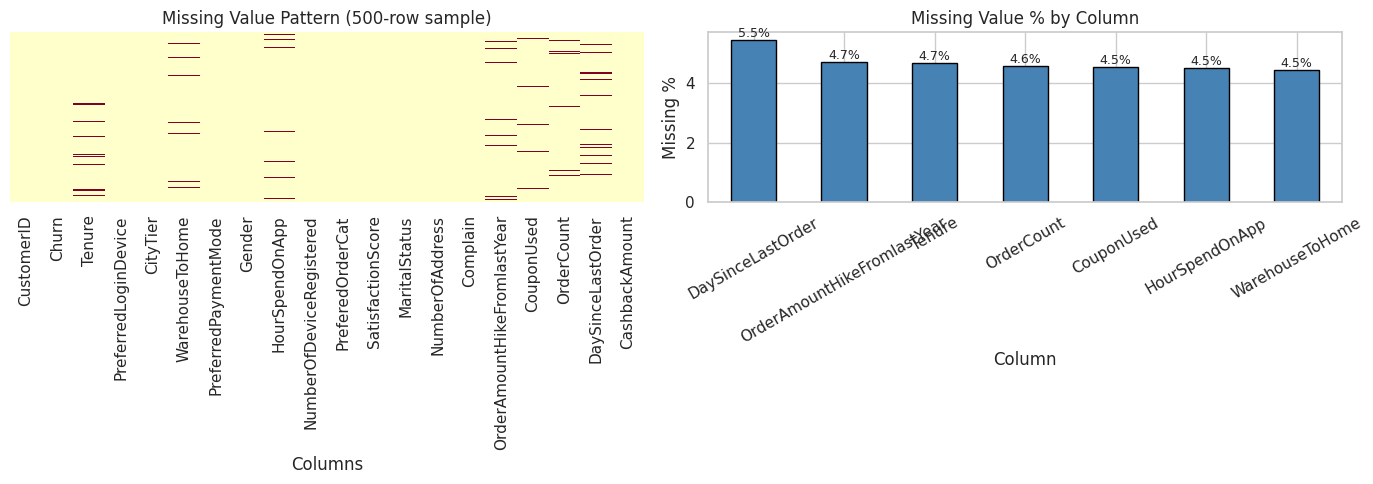

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap (sample 500 rows for readability)
sample = df.sample(500, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Missing Value Pattern (500-row sample)")
axes[0].set_xlabel("Columns")

# Bar chart
na_summary["NA %"].plot(kind="bar", color="steelblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Missing Value % by Column")
axes[1].set_ylabel("Missing %")
axes[1].set_xlabel("Column")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Clean Missing Data

Strategy: fill each numeric column that has NAs with its **median** (robust to skew / outliers).

In [6]:
na_cols = na_summary.index.tolist()
print("Columns to fill:", na_cols)

df_clean = df.copy()
for col in na_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {na_summary.loc[col, 'NA Count']} NAs with median={median_val}")

print(f"\nRemaining NAs after cleaning: {df_clean.isnull().sum().sum()}")

Columns to fill: ['DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 'OrderCount', 'CouponUsed', 'HourSpendOnApp', 'WarehouseToHome']
  DaySinceLastOrder: filled 307 NAs with median=3.0
  OrderAmountHikeFromlastYear: filled 265 NAs with median=15.0
  Tenure: filled 264 NAs with median=9.0
  OrderCount: filled 258 NAs with median=2.0
  CouponUsed: filled 256 NAs with median=1.0
  HourSpendOnApp: filled 255 NAs with median=3.0
  WarehouseToHome: filled 251 NAs with median=14.0

Remaining NAs after cleaning: 0


## 6. Compare Before and After Cleaning

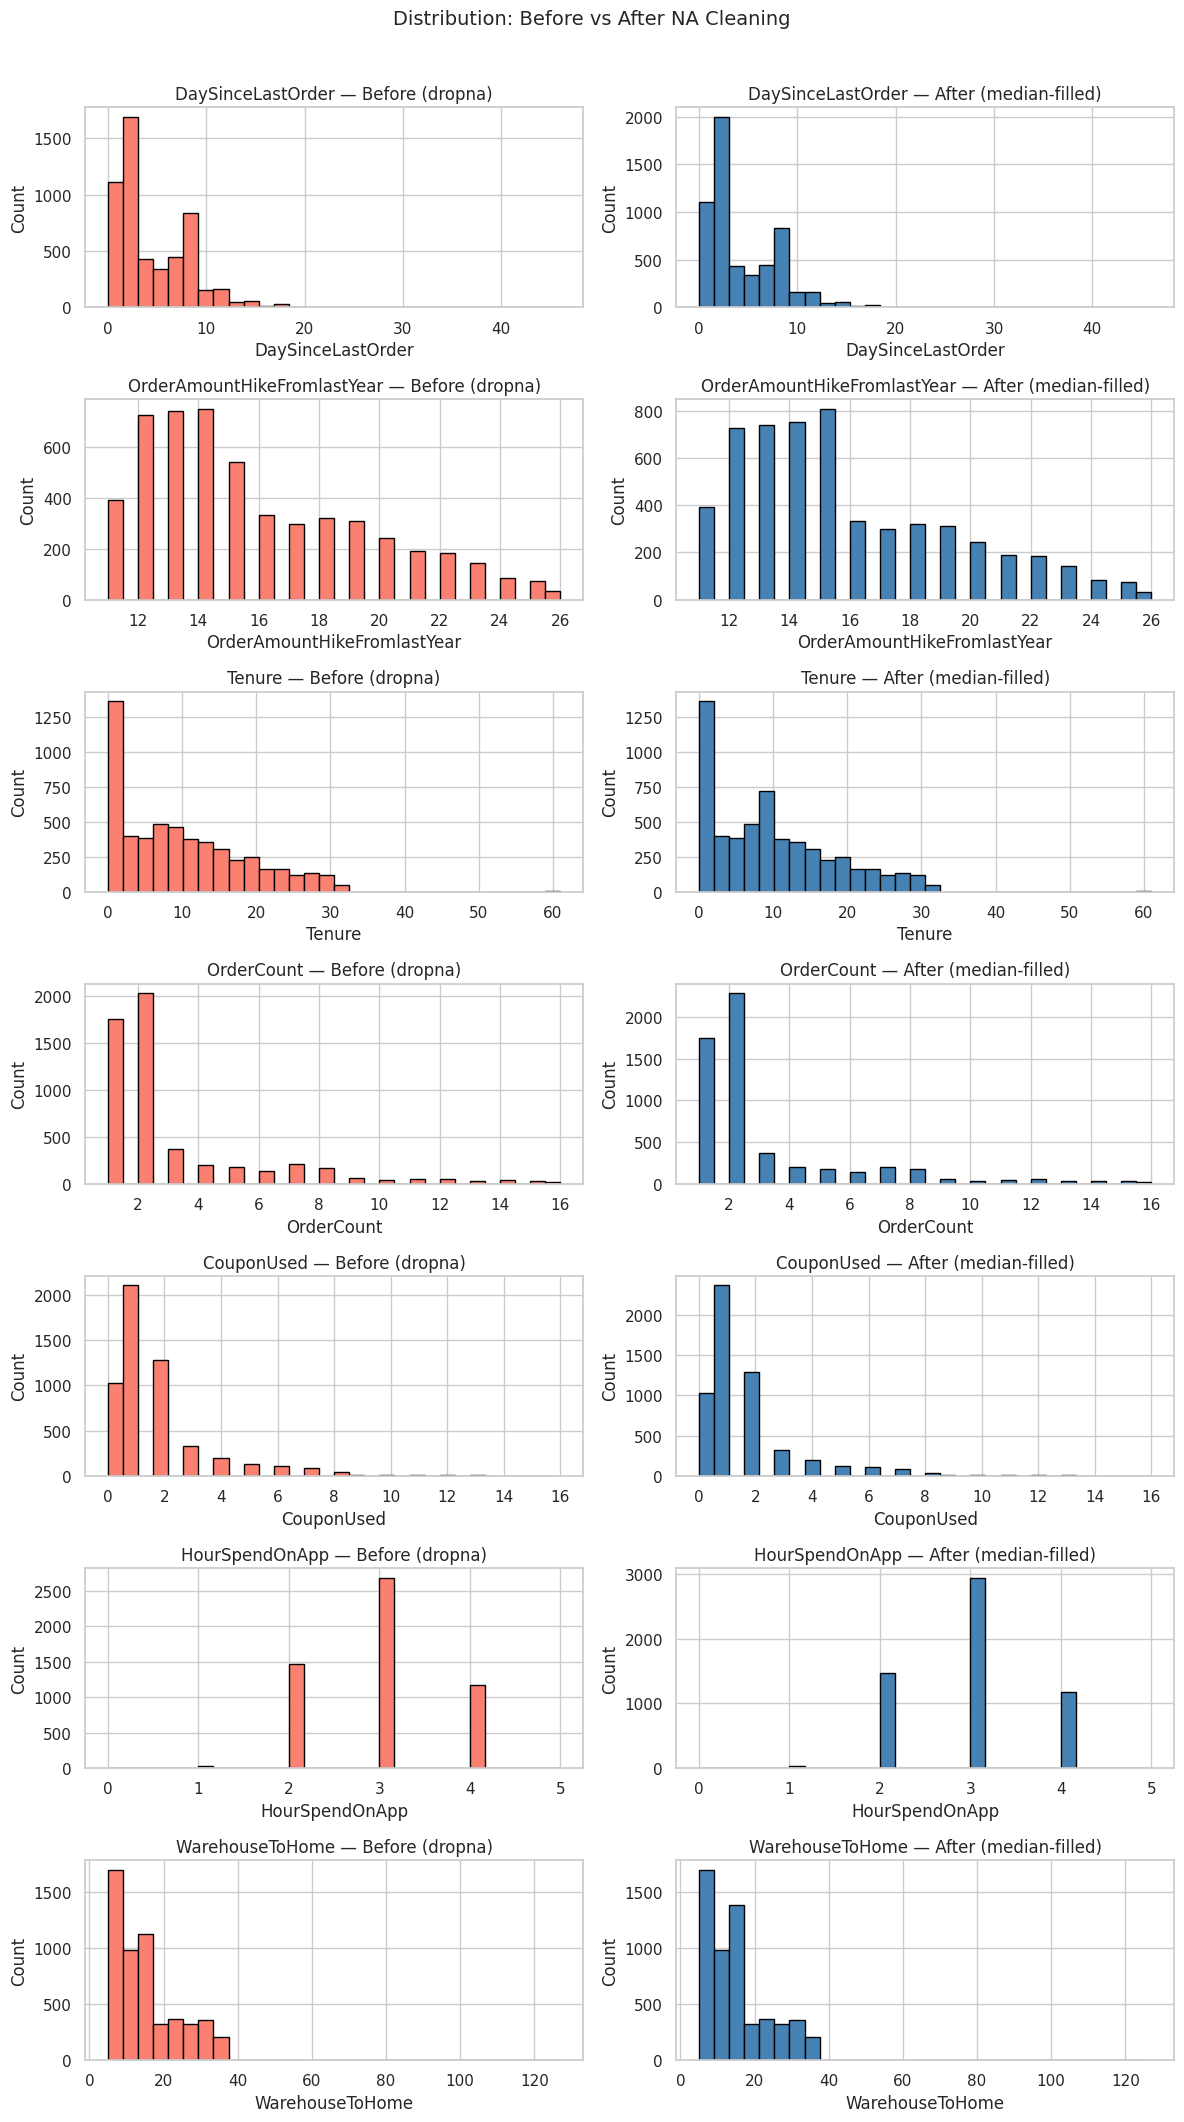

In [7]:
fig, axes = plt.subplots(len(na_cols), 2, figsize=(12, len(na_cols) * 3))

for i, col in enumerate(na_cols):
    # Before
    axes[i, 0].hist(df[col].dropna(), bins=30, color="salmon", edgecolor="black")
    axes[i, 0].set_title(f"{col} — Before (dropna)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # After
    axes[i, 1].hist(df_clean[col], bins=30, color="steelblue", edgecolor="black")
    axes[i, 1].set_title(f"{col} — After (median-filled)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Distribution: Before vs After NA Cleaning", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Churn vs Non-Churn by Feature

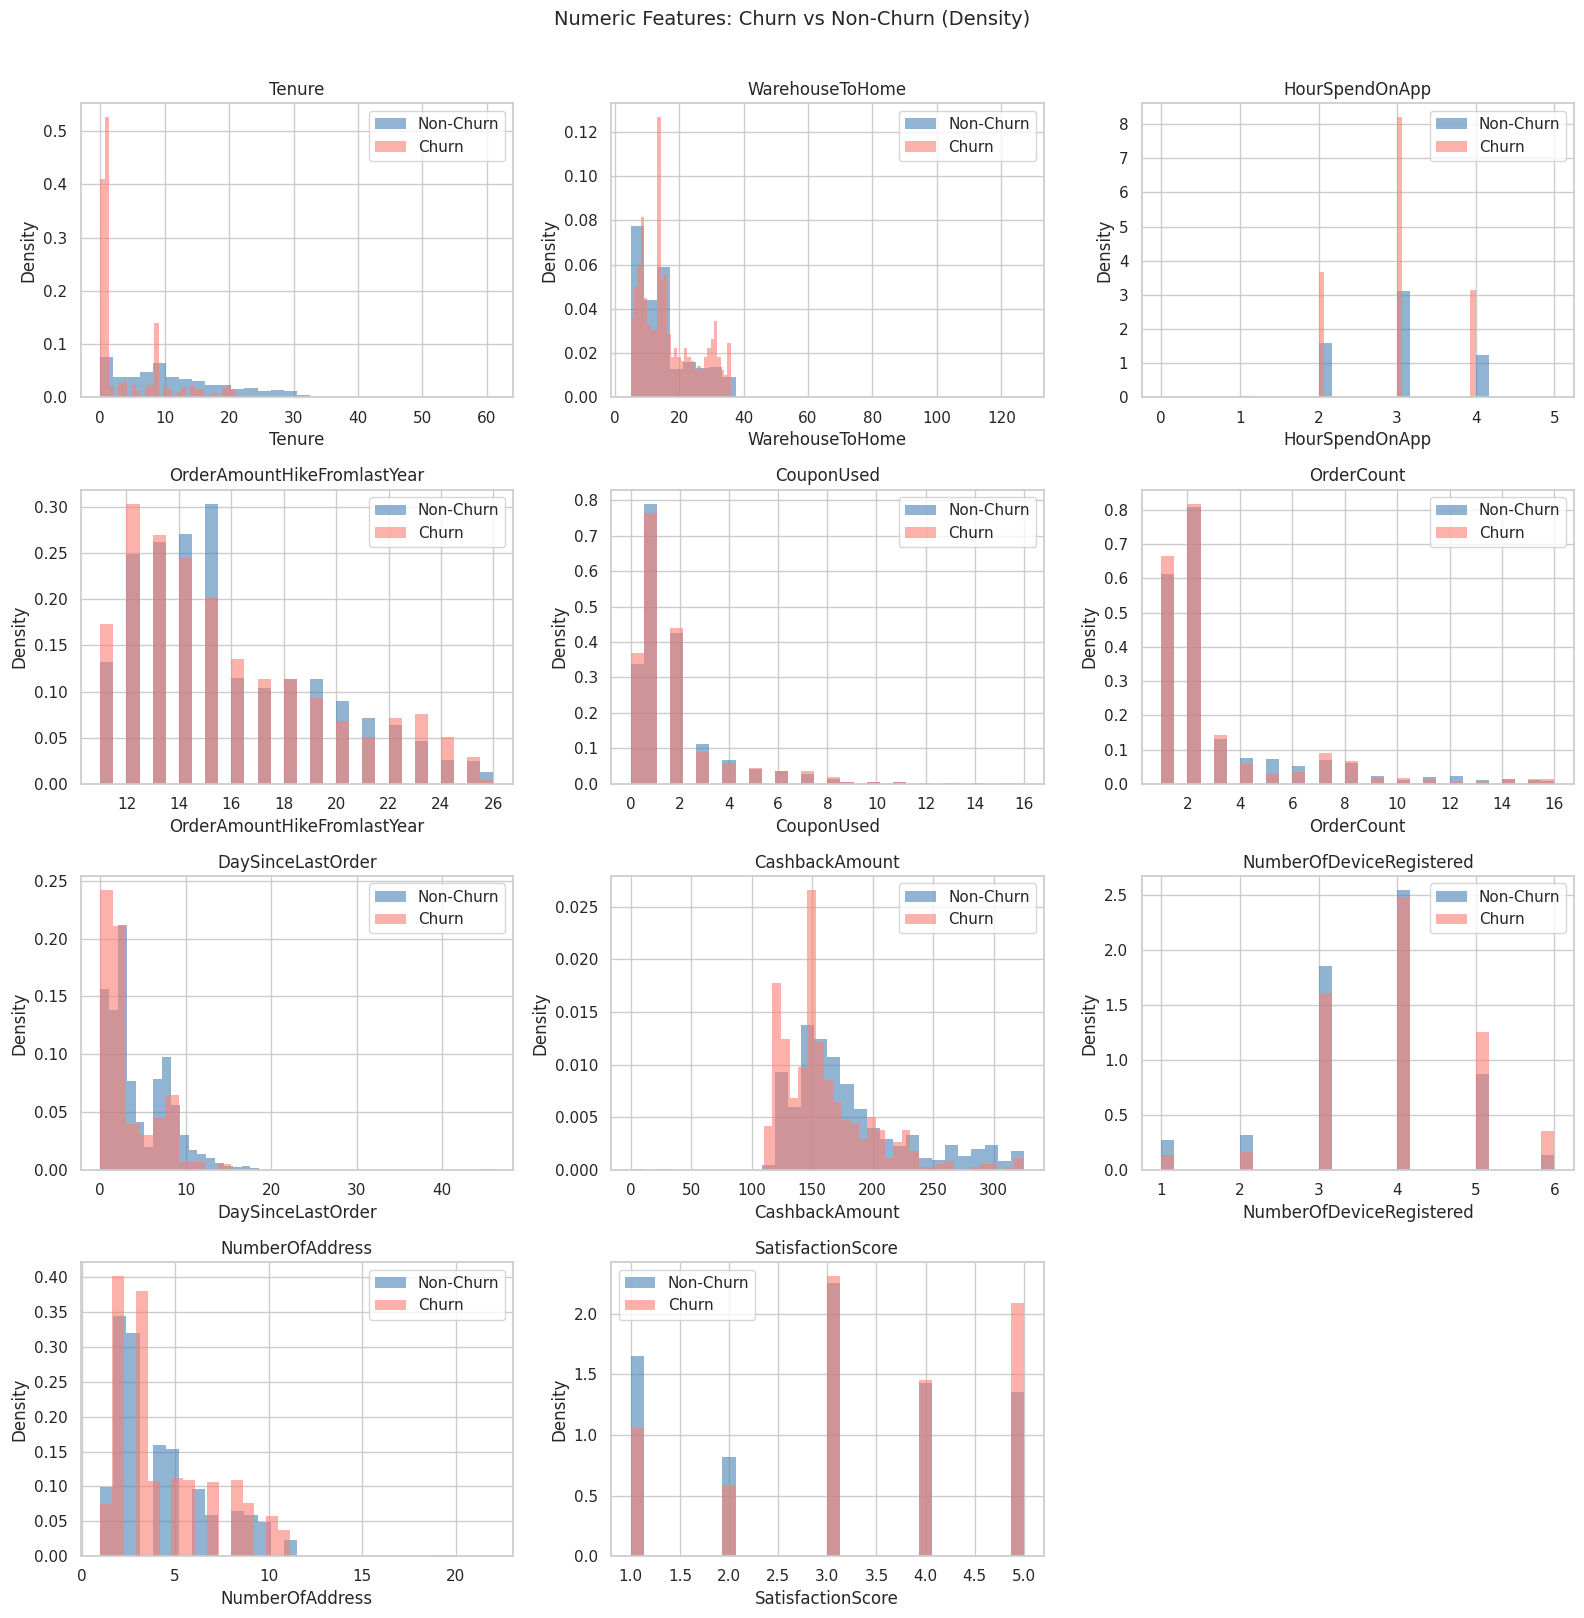

In [8]:
num_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount",
    "DaySinceLastOrder", "CashbackAmount",
    "NumberOfDeviceRegistered", "NumberOfAddress", "SatisfactionScore"
]

n = len(num_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, label, color in [(0, "Non-Churn", "steelblue"), (1, "Churn", "salmon")]:
        subset = df_clean[df_clean["Churn"] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="none", density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

# hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features: Churn vs Non-Churn (Density)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

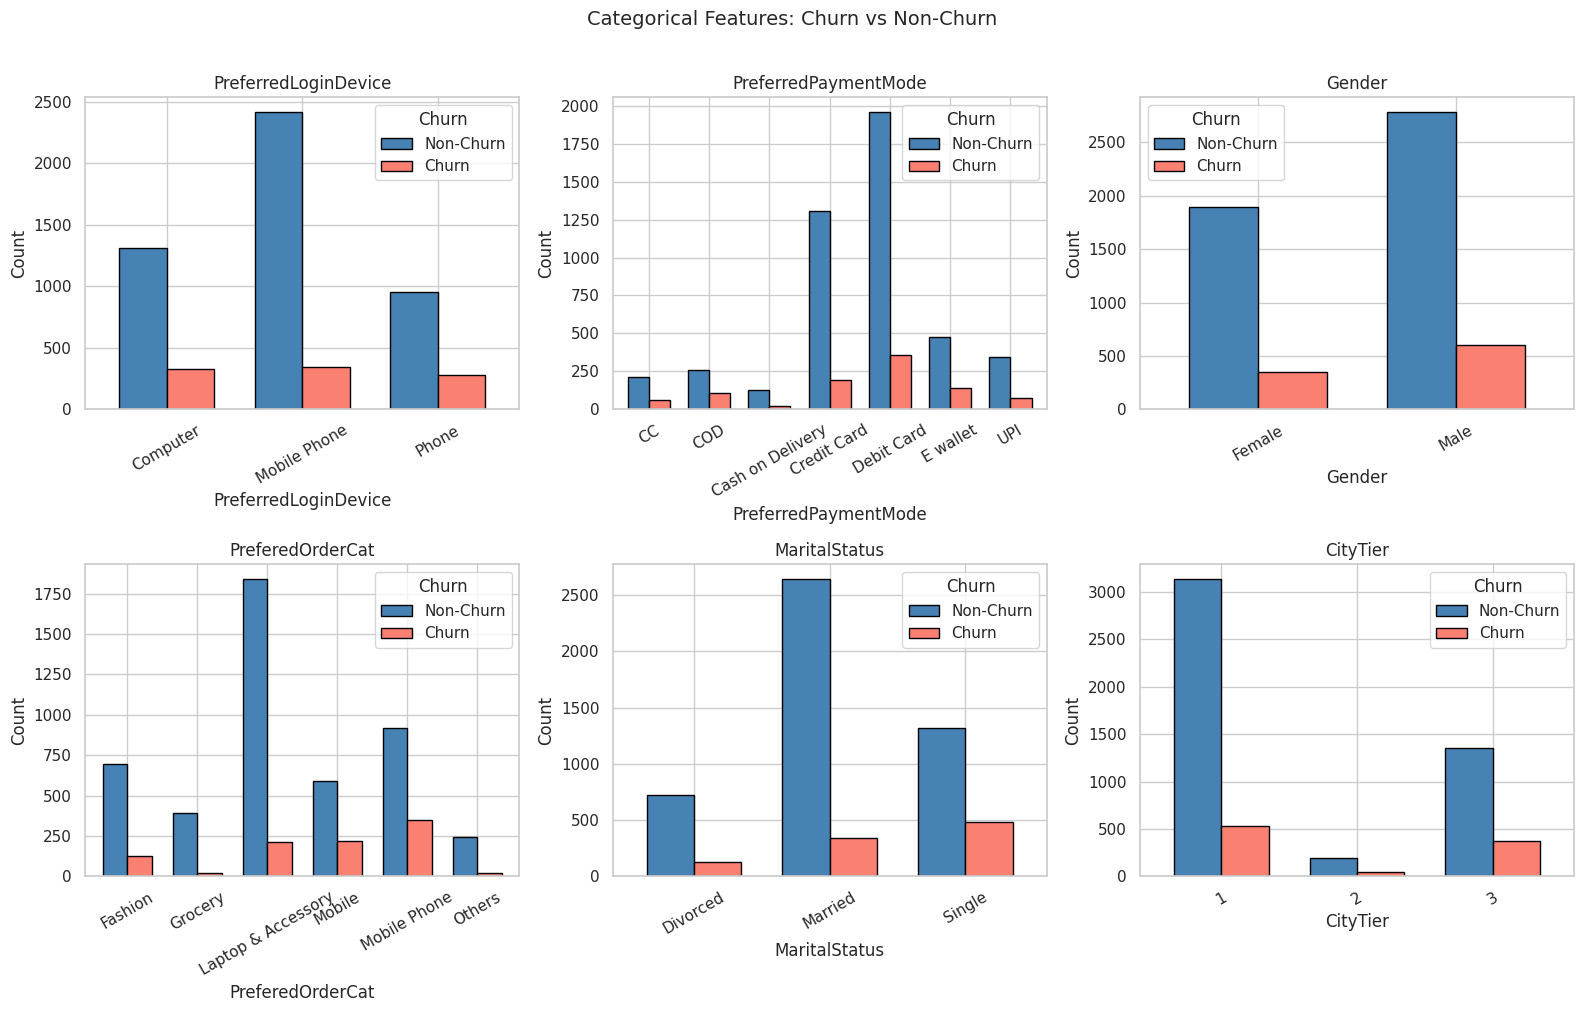

In [9]:
cat_cols = [
    "PreferredLoginDevice", "PreferredPaymentMode",
    "Gender", "PreferedOrderCat", "MaritalStatus", "CityTier"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = (df_clean.groupby([col, "Churn"])
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: "Non-Churn", 1: "Churn"}))
    ct.plot(kind="bar", ax=axes[i], color=["steelblue", "salmon"],
            edgecolor="black", width=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Churn")

plt.suptitle("Categorical Features: Churn vs Non-Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Scatter Plots — Numeric Feature Pairs vs Churn

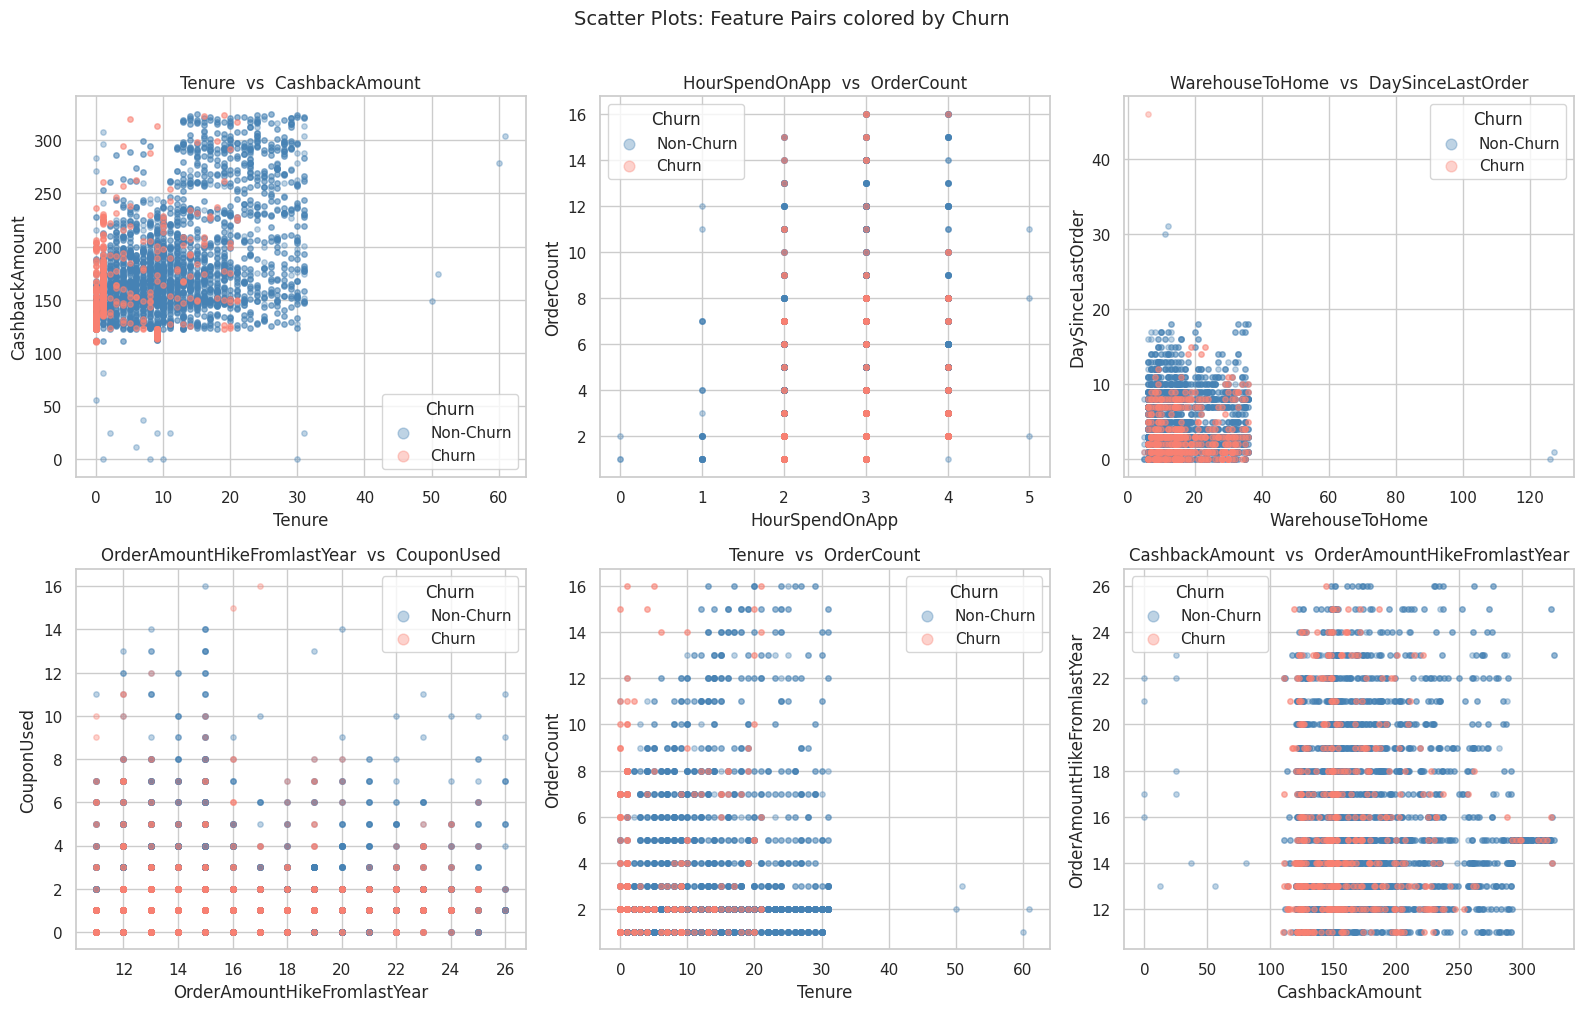

In [10]:
scatter_pairs = [
    ("Tenure",              "CashbackAmount"),
    ("HourSpendOnApp",      "OrderCount"),
    ("WarehouseToHome",     "DaySinceLastOrder"),
    ("OrderAmountHikeFromlastYear", "CouponUsed"),
    ("Tenure",              "OrderCount"),
    ("CashbackAmount",      "OrderAmountHikeFromlastYear"),
]

colors = {0: "steelblue", 1: "salmon"}
labels = {0: "Non-Churn", 1: "Churn"}

n = len(scatter_pairs)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 5))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs):
    for churn_val in [0, 1]:
        subset = df_clean[df_clean["Churn"] == churn_val]
        axes[i].scatter(
            subset[x_col], subset[y_col],
            alpha=0.35, s=15,
            color=colors[churn_val],
            label=labels[churn_val]
        )
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f"{x_col}  vs  {y_col}")
    axes[i].legend(title="Churn", markerscale=2)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Scatter Plots: Feature Pairs colored by Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Pairplot — Key Numeric Features by Churn

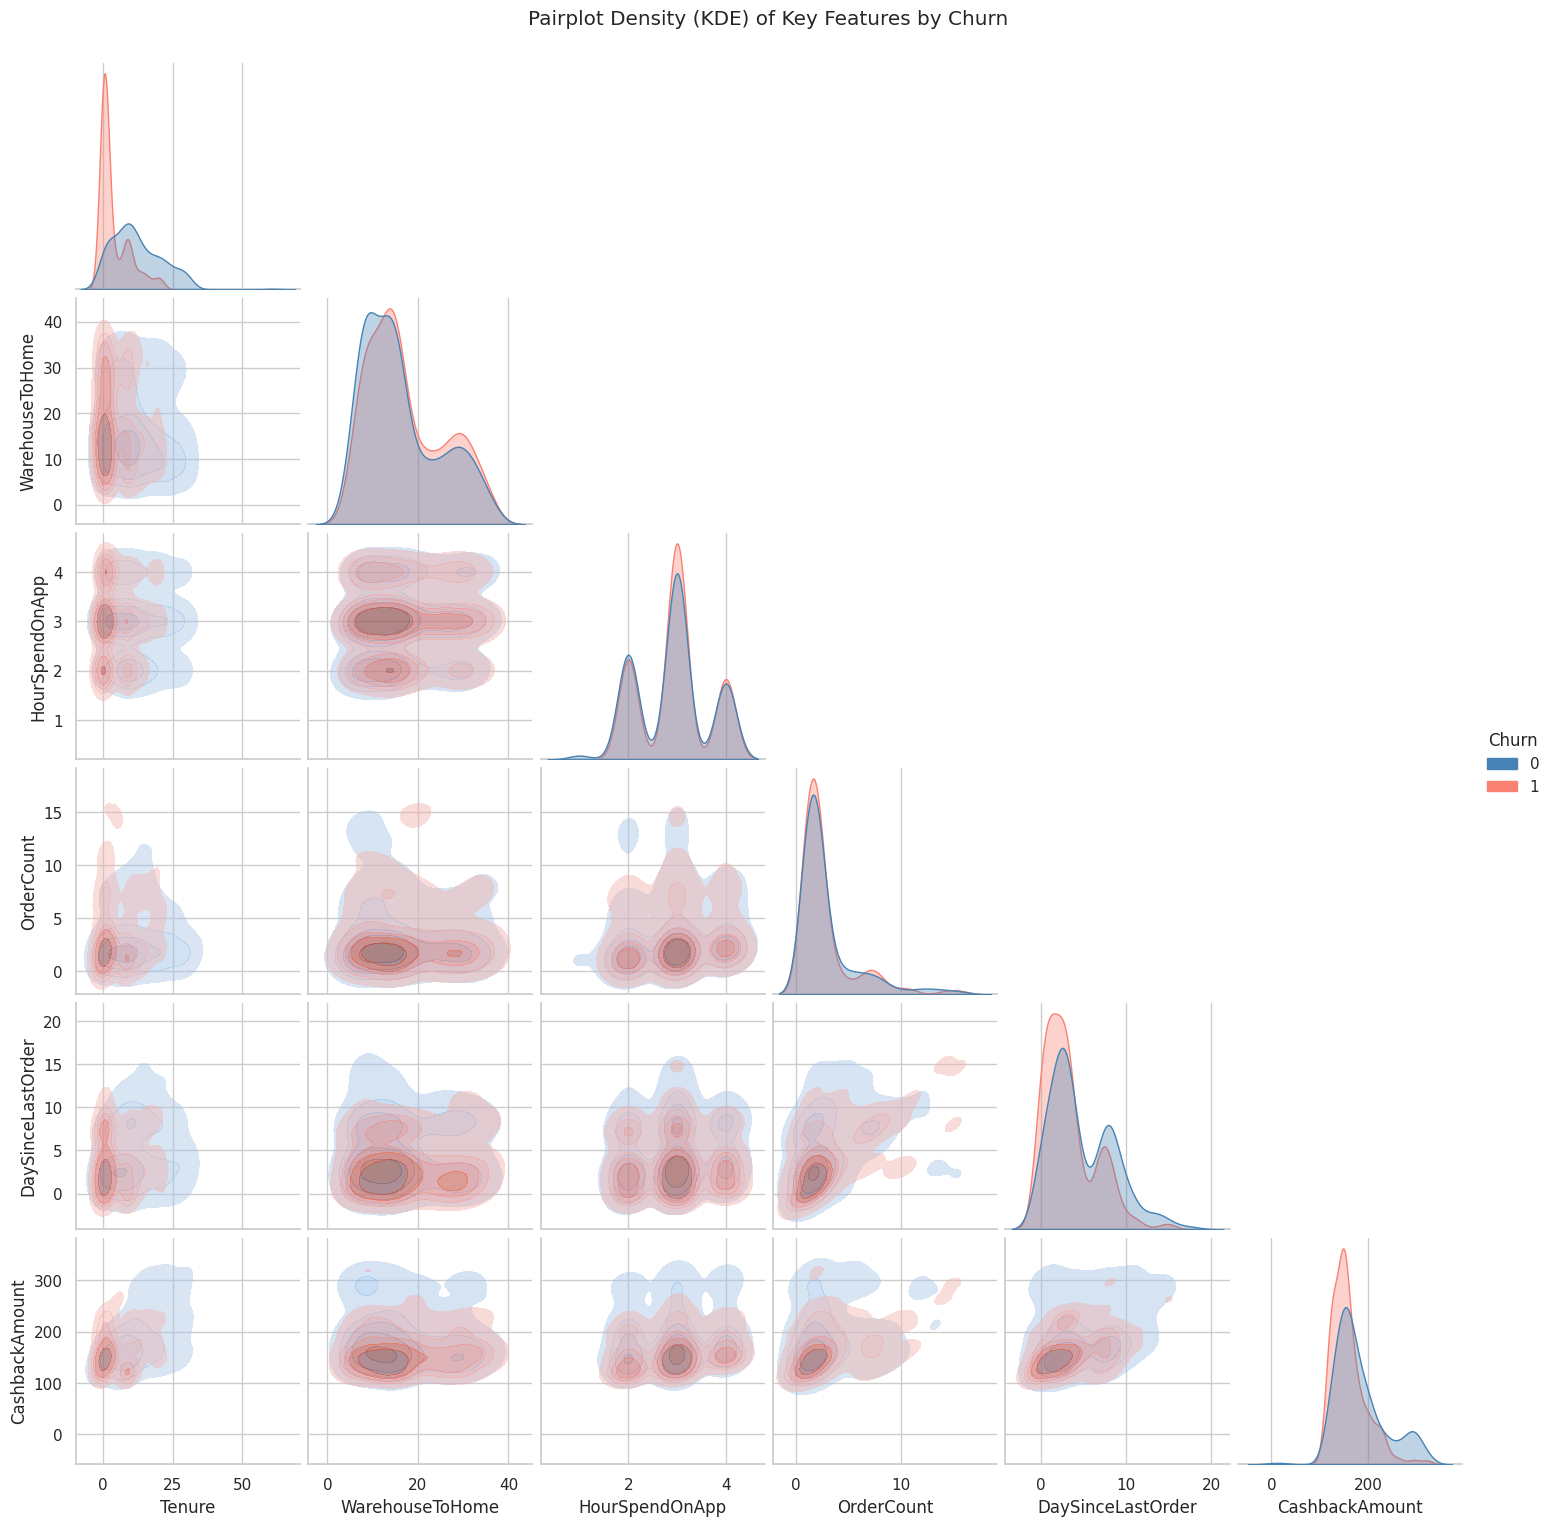

In [11]:
pairplot_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderCount", "DaySinceLastOrder", "CashbackAmount",
    "Churn"
]

# Sample for faster rendering (keep class ratio by sampling within each churn class).
base = df_clean[pairplot_cols].dropna()
pairplot_data = pd.concat(
    [
        grp.sample(n=min(400, len(grp)), random_state=42)
        for _, grp in base.groupby("Churn")
    ],
    ignore_index=True
)

g = sns.pairplot(
    data=pairplot_data,
    vars=[c for c in pairplot_cols if c != "Churn"],
    hue="Churn",
    corner=True,
    kind="kde",
    diag_kind="kde",
    plot_kws={"fill": True, "levels": 6, "thresh": 0.05, "alpha": 0.45},
    diag_kws={"fill": True, "common_norm": False, "alpha": 0.35},
    palette={0: "steelblue", 1: "salmon"}
)

g.fig.suptitle("Pairplot Density (KDE) of Key Features by Churn", y=1.02)
plt.show()

# 10. RFM Analysis & Customer Segmentation (Clustering)

## 10.1 Feature Selection for RFM
We will create an RFM-like segmentation using:
- **Recency**: `DaySinceLastOrder`
- **Frequency**: `OrderCount`
- **Monetary**: `CashbackAmount` (as a proxy for monetary value since total spend is not available)

We will also include `Tenure`, `CouponUsed`, `Complain`, and `SatisfactionScore` to add more depth to our clusters.

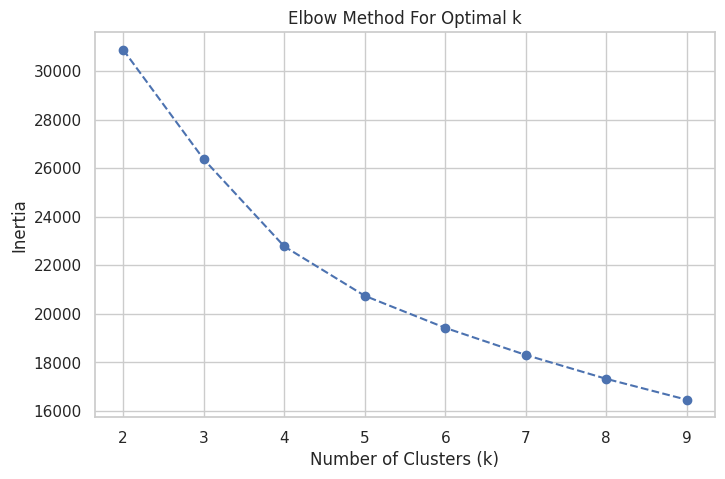

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Select features for clustering
cluster_cols = ['DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Tenure', 'CouponUsed', 'Complain', 'SatisfactionScore']

# For clustering, we need non-null data. Let's use the cleaned dataframe 'df_clean' if it exists, otherwise fill na
# We assume df_clean is available from earlier cells
if 'df_clean' in locals() or 'df_clean' in globals():
    df_cluster = df_clean[cluster_cols + ['CustomerID', 'Churn']].copy()
else:
    # Fallback if running independently
    df_cluster = pd.read_csv('data/Ecommerce Customer Churn.csv')
    df_cluster = df_cluster[cluster_cols + ['CustomerID', 'Churn']].copy()
    for col in cluster_cols:
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

df_cluster = df_cluster.dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_cols])

# Determine optimal number of clusters using Elbow Method
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


## 10.2 K-Means Clustering
Based on the elbow method, we will choose `k=4` (or `k=5`) clusters to segment our customers into distinct groups.

In [13]:
# Apply K-Means with k=4
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Profiling
cluster_summary = df_cluster.groupby('Cluster').agg({
    'DaySinceLastOrder': 'mean',
    'OrderCount': 'mean',
    'CashbackAmount': 'mean',
    'Tenure': 'mean',
    'CouponUsed': 'mean',
    'Complain': 'mean',
    'SatisfactionScore': 'mean',
    'Churn': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(2)

display(cluster_summary)


,DaySinceLastOrder,OrderCount,CashbackAmount,Tenure,CouponUsed,Complain,SatisfactionScore,Churn,CustomerCount
Cluster,,,,,,,,,
0,3.51,1.90,156.12,7.11,1.12,0.00,3.10,0.14,2777
1,3.26,2.00,159.64,7.32,1.17,1.00,2.99,0.36,1197
2,5.94,2.62,246.79,21.71,1.48,0.23,2.98,0.03,894
3,8.06,8.73,200.13,11.99,5.00,0.27,3.15,0.15,762


## 10.3 Dimensionality Reduction (PCA & t-SNE) for Visualization
We will use PCA and t-SNE to reduce the dimensions to 2D and visualize how the clusters separate.

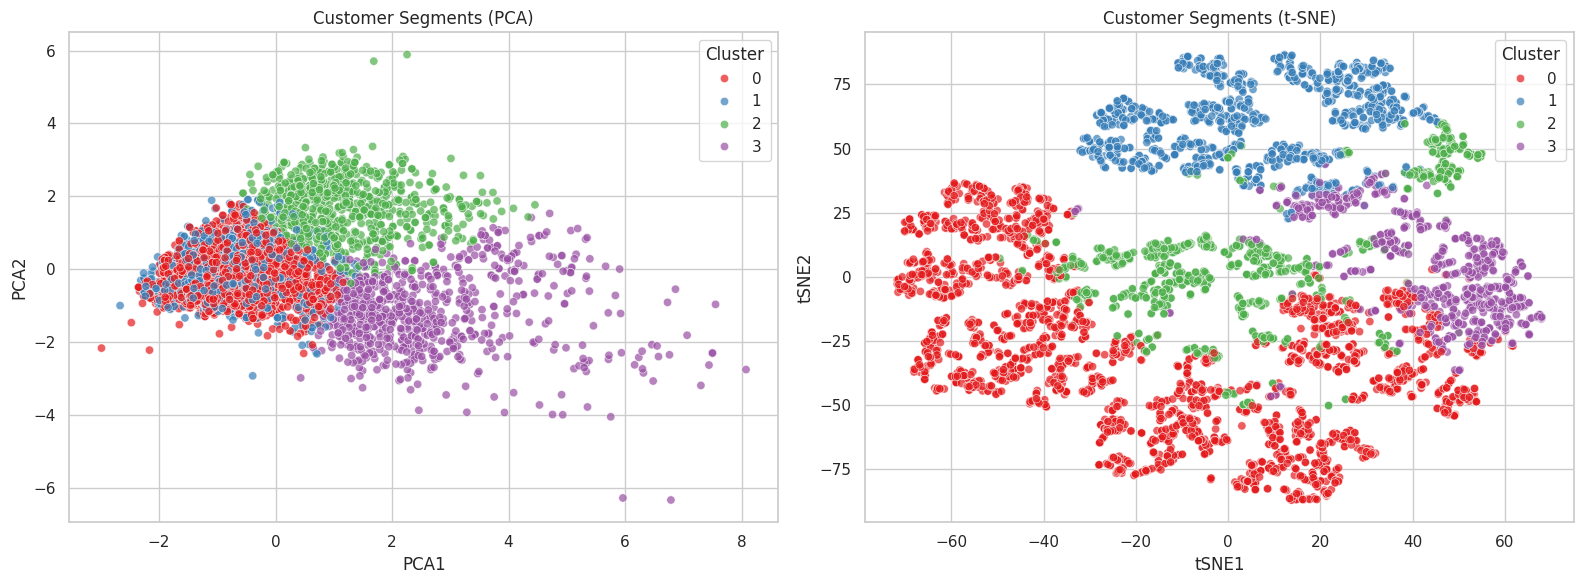

In [14]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = pca_res[:, 0]
df_cluster['PCA2'] = pca_res[:, 1]

# t-SNE (Sampled for performance if dataset is large, but 5k is fine)
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne_res = tsne.fit_transform(X_scaled)
df_cluster['tSNE1'] = tsne_res[:, 0]
df_cluster['tSNE2'] = tsne_res[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_cluster, palette='Set1', ax=ax[0], alpha=0.7)
ax[0].set_title('Customer Segments (PCA)')

# Plot t-SNE
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster', data=df_cluster, palette='Set1', ax=ax[1], alpha=0.7)
ax[1].set_title('Customer Segments (t-SNE)')

plt.tight_layout()
plt.show()


## 10.4 Business Insights & Strategic Recommendations based on Segments

Based on the cluster summary above, we can identify distinct customer personas and tailor our strategies:

**Cluster 0: The "High-Value Loyalists"**
- **Characteristics:** High OrderCount, high CashbackAmount, long Tenure. Low churn rate.
- **Action:** Retain and Reward. They don't need heavy couponing to stay. Offer them VIP perks, early access to new products, or exclusive premium items. Pushing high-margin products here is effective.

**Cluster 1: The "At-Risk / Recent Churners"**
- **Characteristics:** High churn rate, often recent buyers (low DaySinceLastOrder) but low satisfaction or high complaints.
- **Action:** Win-back campaign. These customers are likely unhappy. DO NOT just send generic coupons. Address their complaints directly. Offer targeted "We Miss You" coupons with deep discounts on categories they previously bought (e.g., Mobile/Laptop) to rebuild trust.

**Cluster 2: The "Coupon-Driven Bargain Hunters"**
- **Characteristics:** High CouponUsed, moderate OrderCount. They buy when there's a deal.
- **Action:** Targeted Promotions. Keep them engaged with regular, time-sensitive coupons. They have a high churn risk if promotions stop. Push inventory that needs clearing or bundle deals to increase their basket size.

**Cluster 3: The "New / Low Engagement"**
- **Characteristics:** Low Tenure, low OrderCount. They haven't formed a habit yet.
- **Action:** Onboarding and Activation. Provide aggressive first-month discounts (e.g., 20% off next purchase) to build frequency. Push popular, high-conversion everyday items to get them accustomed to the platform. If they don't engage after 30 days, they might be worth letting go to focus resources on other segments.

### Summary of Coupon Strategy:
- **Who to give coupons to:** Cluster 2 (Bargain Hunters) to maintain volume, and Cluster 3 (New) for activation. Cluster 1 (At-Risk) needs targeted apology/win-back coupons.
- **Who to skip (save margin):** Cluster 0 (Loyalists). They buy anyway; reward them with experience, not discounts.
- **Products to push:** High-margin to Cluster 0, Clearance/Bundles to Cluster 2, Popular/Gateway items to Cluster 3.


## 10.5 Product Category Preferences by Segment

To make our coupon strategy truly effective, we need to know *what* to offer to each cluster. Let's merge the `PreferedOrderCat` back into our clustered data and visualize the patterns.

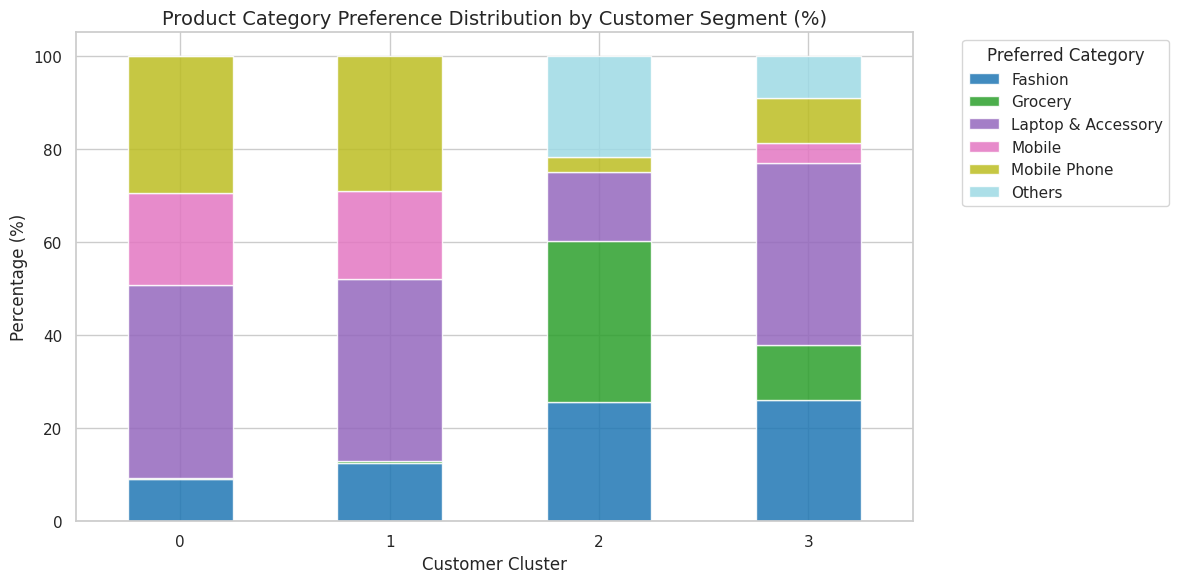

PreferedOrderCat,Fashion,Grocery,Laptop & Accessory,Mobile,Mobile Phone,Others
Cluster,,,,,,
0,9.0,0.1,41.4,19.8,29.5,0.0
1,12.4,0.4,39.2,18.8,29.2,0.0
2,25.5,34.7,14.9,0.0,3.2,21.7
3,26.0,11.9,39.0,4.3,9.7,9.1


In [15]:
# Add Category back to the cluster dataframe
# Note: Ensure the indices align since df_cluster had nulls dropped
df_cluster['PreferedOrderCat'] = df_clean.loc[df_cluster.index, 'PreferedOrderCat'] if 'df_clean' in locals() else pd.read_csv('data/Ecommerce Customer Churn.csv').loc[df_cluster.index, 'PreferedOrderCat']

# Calculate distribution of categories per cluster
category_dist = pd.crosstab(df_cluster['Cluster'], df_cluster['PreferedOrderCat'], normalize='index') * 100

# Plotting the stacked bar chart for category preferences
plt.figure(figsize=(12, 6))
category_dist.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20', alpha=0.85)

plt.title('Product Category Preference Distribution by Customer Segment (%)', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Customer Cluster', fontsize=12)
plt.legend(title='Preferred Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(category_dist.round(1))


## 10.6 Deep Dive Product & Coupon Strategy

Based on the distribution of what each cluster likes to buy, we can refine our strategy to push the right products:

**Pattern Observation:**
1. **Mobiles / Mobile Phones** generally have a higher churn risk overall compared to Grocery or Laptops.
2. If a cluster heavily indexes on **Laptop & Accessory**, they might be buying higher ticket items less frequently, which explains their high value but potentially longer recency.

**Tailored Product Push Strategies:**

- **Cluster 0 (The "High-Value Loyalists")**
  - *What they buy:* Likely a solid mix of Laptops and Accessories.
  - *Strategy:* **Push 70% Premium/Accessories, 30% Cross-sell.** Since they are loyal, push high-margin accessories (e.g., premium headphones, laptop bags) that complement their past big purchases. We do *not* need to discount heavily here. Give them "Early Access" to new tech drops instead of % off coupons.

- **Cluster 1 (The "At-Risk / Recent Churners")**
  - *What they buy:* Look for high spikes in Mobile Phones. This segment is highly volatile.
  - *Strategy:* **Push 80% Win-back core items, 20% Essentials.** If they bought a mobile phone and churned, they might have had a bad experience. Offer them a steep discount (e.g., "We messed up, here is 30% off your next Mobile Accessory"). The goal is entirely to regain trust.

- **Cluster 2 (The "Coupon-Driven Bargain Hunters")**
  - *What they buy:* Often spread across Fashion and Mobiles. They follow the sales.
  - *Strategy:* **Push 60% Clearance/High-Inventory items, 40% Fashion bundles.** They don't necessarily care about the newest model; they care about the "deal". Offer them BOGO (Buy One Get One) on Fashion or heavy discounts on older Mobile models. Give them a coupon that requires a minimum spend (e.g., "$20 off $100") to maximize basket size.

- **Cluster 3 (The "New / Low Engagement")**
  - *What they buy:* Often entry-level or Gateway items (like Groceries or basic Accessories).
  - *Strategy:* **Push 90% High-Conversion / Gateway items.** Don't show them a $1,000 laptop yet. Push fast-moving consumer goods (Grocery/Basic Fashion) with a heavy "First Month 20% Off" coupon. We want them to form a habit of checking out on the app.

**Should we let anyone go?**
If a customer falls into **Cluster 1** or **Cluster 3**, buys a low-margin item (like basic grocery), files a complaint, and doesn't return after 1 win-back coupon—we should **stop sending them marketing materials and let them churn.** The CAC (Customer Acquisition Cost) to retain a low-margin, high-complaint user is not worth the business return.


## 10.7 Deep Dive: Cluster 0 (Loyalists) vs Cluster 1 (At-Risk)

Let's visualize exactly what makes our "High-Value Loyalists" (Cluster 0) different from the "At-Risk / Recent Churners" (Cluster 1). We'll plot `Tenure` (How long they've been with us) against `CashbackAmount` (A proxy for their spending value).

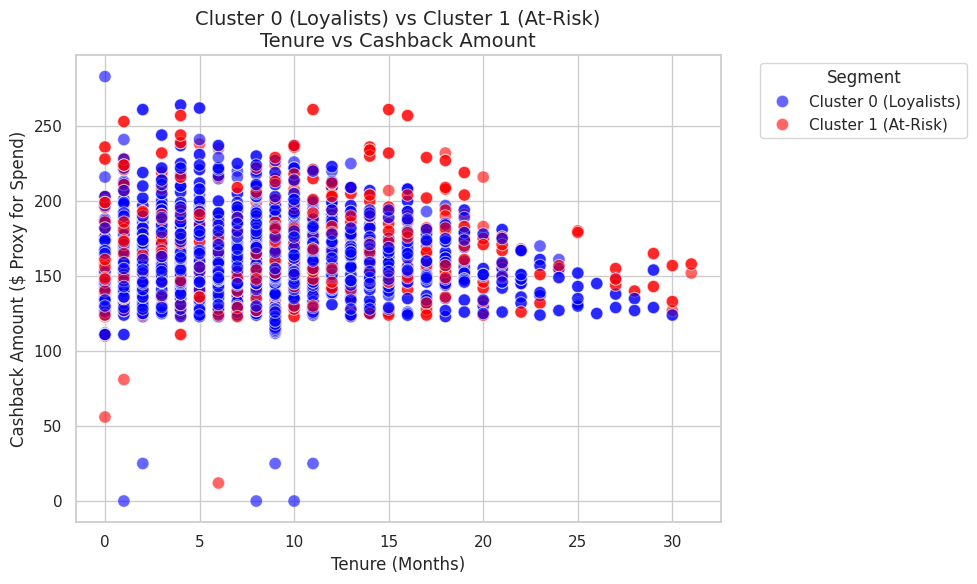

In [16]:
# Filter data for only Cluster 0 and Cluster 1
df_01 = df_cluster[df_cluster['Cluster'].isin([0, 1])]

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_01,
    x='Tenure',
    y='CashbackAmount',
    hue='Cluster',
    palette={0: 'blue', 1: 'red'},
    alpha=0.6,
    s=80,
    edgecolor='w'
)

plt.title('Cluster 0 (Loyalists) vs Cluster 1 (At-Risk)\nTenure vs Cashback Amount', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Cashback Amount ($ Proxy for Spend)', fontsize=12)

# Custom legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Cluster 0 (Loyalists)', 'Cluster 1 (At-Risk)'], title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Key Takeaways from the Scatter Plot:

1. **Tenure Gap:** Cluster 1 (Red) is heavily clustered on the left side (low tenure). These are newer customers who quickly churned or became at-risk. Cluster 0 (Blue) spreads far to the right, showing deep, long-term loyalty.
2. **Spend Gap:** Cluster 0 generally has a higher `CashbackAmount` floor compared to the dense mass of Cluster 1 at the lower end, indicating Loyalists consistently spend more.
3. **Conclusion:** The difference between these two isn't just that one happens to buy Laptops and one buys Phones; it's that **Cluster 1 fails to mature**. They come in, spend relatively less, and leave quickly. Our win-back coupons for Cluster 1 *must* happen early in their lifecycle before they permanently attrite.